# **Análisis Preliminar**

## **Librerías**

In [286]:
import pandas as pd
from scipy.stats import shapiro
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp

## **Funciones**

In [287]:
def prueba_normalidad_shap (df, variable):
    stat, p = shapiro(df[variable].dropna())
    print('Estadístico=%.3f, p=%.3f' % (stat, p))

    if p > 0.05:
        print('No se rechaza H0 → parece normal')
    else:
        print('Se rechaza H0 → no es normal')

In [288]:
def analizar_misma_variable(df1, df2, columna, color1="#4682B4", color2="#FF6347"):
    # Crear una figura con dos filas y dos columnas
    f, ((ax_box1, ax_hist1), (ax_box2, ax_hist2)) = plt.subplots(2, 2, sharex='col', figsize=(12, 10))
    
    # Primer par de gráficos (boxplot y histograma para columna en df1)
    sns.boxplot(x=df1[columna], ax=ax_box1, color=color1, fliersize=5)
    ax_box1.set(xlabel='') 
    ax_box1.set_title(f'Distribución de la Variable: {columna} en df1', fontsize=14)
    
    sns.histplot(df1[columna], ax=ax_hist1, kde=True, color=color1, bins=30)
    ax_hist1.set_xlabel(f'Valores de {columna}', fontsize=12)
    ax_hist1.set_ylabel('Frecuencia', fontsize=12)
    
    # Segundo par de gráficos (boxplot y histograma para columna en df2)
    sns.boxplot(x=df2[columna], ax=ax_box2, color=color2, fliersize=5)
    ax_box2.set(xlabel='') 
    ax_box2.set_title(f'Distribución de la Variable: {columna} en df2', fontsize=14)
    
    sns.histplot(df2[columna], ax=ax_hist2, kde=True, color=color2, bins=30)
    ax_hist2.set_xlabel(f'Valores de {columna}', fontsize=12)
    ax_hist2.set_ylabel('Frecuencia', fontsize=12)
    
    plt.tight_layout()  # Ajustar espaciado
    plt.show()

In [289]:
def analizar_distribucion(df, columna, color="#4682B4"):
    f, (ax_box, ax_hist) = plt.subplots(2, sharex=True, 
                                        gridspec_kw={"height_ratios": (.15, .85)},
                                        figsize=(8, 6))
    
    sns.boxplot(x=df[columna], ax=ax_box, color=color, fliersize=5)
    ax_box.set(xlabel='') 
    ax_box.set_title(f'Distribución de la Variable: {columna}', fontsize=14)
    
    sns.histplot(df[columna], ax=ax_hist, kde=True, color=color, bins=30)
    ax_hist.set_xlabel(f'Valores de {columna}', fontsize=12)
    ax_hist.set_ylabel('Frecuencia', fontsize=12)
    
    plt.tight_layout()
    plt.show()

In [290]:
def distribucion_cruzada (df_original, df_imputed, variable):
    sns.kdeplot(df_original[variable].dropna(), label='Original')
    sns.kdeplot(df_imputed[variable], label='Imputado')
    plt.legend()
    plt.show()

In [291]:
def Resumen_Faltantes(df):
    faltantes = df.isnull().sum()
    porcentaje = (faltantes / len(df)) * 100

    tabla_faltantes = pd.DataFrame({
        'Valores faltantes': faltantes,
        'Porcentaje (%)': porcentaje
    })

    # Mostrar solo columnas con NA
    tabla_faltantes = tabla_faltantes[tabla_faltantes['Valores faltantes'] > 0]
    tabla_faltantes.sort_values('Porcentaje (%)', ascending=False)
    return tabla_faltantes

In [292]:
def resumen_var_cat(df, excluir=None, top_n=10):

    serie = df.copy()
    
    # Excluir una o varias categorías
    if excluir is not None:
        if isinstance(excluir, list):
            serie = serie[~serie.isin(excluir)]
        else:
            serie = serie[serie != excluir]
    
    conteo = serie.value_counts(dropna=False)
    porcentaje = serie.value_counts(normalize=True, dropna=False) * 100
    
    resumen = pd.DataFrame({
        'categorias': conteo.index,
        'conteo': conteo.values,
        'porcentaje': porcentaje.values.round(2)
    })
    
    resumen = resumen.head(top_n)
    
    styled = resumen.style.format({'porcentaje': '{:.2f}%'})
    display(styled)

In [293]:
def resumen_var_cat(df):
    conteo = df.value_counts(dropna=False)
    porcentaje = df.value_counts(normalize=True, dropna=False) * 100
    
    resumen = pd.DataFrame({
        'categorias': conteo.index,
        'conteo': conteo.values,
        'porcentaje': porcentaje.values.round(2)
    })
    
    resumen = resumen.head(10)  # opcional
    
    # 🎨 estilo bonito
    styled = resumen.style \
        .format({'porcentaje': '{:.2f}%'})
    
    display(styled)

In [294]:
def prueba_kolmogrov(df_original,df_imputed,variable):
    stat, p = ks_2samp(df_original[variable].dropna(), df_imputed[variable].dropna())
    print(f"KS statistic: {stat:.3f}, p-value: {p:.3f}")

    if(p > 0.05):
        print("No hay evidencia estadísticamente significativa que evidencia que las distribuciones difieran")
    else:
        print("La distribución cambió significativamente")

In [295]:
def imputacion_por_mediana(df, columna):
    # 1. Calcular la mediana de la columna
    mediana = df[columna].median()

    # 2. Imputar los valores faltantes con la mediana
    df[columna].fillna(mediana, inplace=True)

    return df

## **Importar base de datos**

Inicialmente se importa la base de datos para verificar sus variables y proceder con diferentes correcciones.

In [296]:
df = pd.read_excel("df_afro_clean.xlsx")

In [297]:
pd.set_option("display.max_columns", None)
df.head()

,GRUPO,Departamento_Tamizaje,Municipio_Tamizaje,Edad,Genero,Escolaridad,Regimen_Salud,Ocupacion,Medicacion_Diabetes,Diabetes_Embarazo,Hipertension,Medicacion_Hipertension,Colesterol_Alto,Medicacion_Colesterol,Insuficiencia_Renal,Dialisis,Proteina_Sangre_Orina,Alergias,Nombre_Alergenos,Consumo_Tabaco,Fumador_100Cigs,Cantidad_Fumador,Consumo_Alcohol,Frecuencia_Alcohol,Embriaguez,Consumo_Drogas,Trabajo_Cultivo,Uso_Insecticidas,Uso_Fungicidas,Uso_Fertilizantes,Proteccion_Pesticidas,Metodo_Aplicacion_Pesticidas,Sintomas_Trabajo,Consumo_Agua_Trabajo,Ultima_Consulta_Medica,Dificultad_Atencion_Medica,Ultimo_Profesional_Salud,Medico_Cabecera,Grupo_Sanguineo,Transfusion_Sanguinea,Antecedentes_Familiares,Familiar_Insuficiencia_Renal,Familiar_Dialisis,Sintomas_Recientes,Uso_AINES,Uso_Medicina_Natural,Fuente_Agua,Peso,Talla,IMC,Tirilla_Reactiva,Creatinina,TFG_CDK_EPI,TFG_Edad,Presion_Sistolica,Presion_Diastolica,Creatinina_Alta,Presion_Sistolica\t> 130,Presion_Diastolica > 90,Categoria_Talla,Categoria_Peso,Categoria_IMC
0,AFRODESCENDIENTE,BOLIVAR,MARIA LA BAJA,57,Femenino,Primaria,Subsidiado,Desempleado,Si,No,Si,Si,Si,Si,No,No,No,No,No aplica,No,No,NaN,No,Nunca,No,No,No,No,No,No,No aplica,No aplica,No siente nada,Mas de 1 litro,Mayor a 3 meses,Muy Dificil,Internista,Si,B+,No,Hipertensión Arterial,No,No,Ninguno,No,No,Suministro municipal,63,1.66,22.862534,Negativo,0.9,82.26,73.0,175.0,89.0,No,1,0,1.61-1.70,61-80,Normal
1,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,28,Femenino,Secundaria,Subsidiado,Desempleado,No,Sí,No,No,No,No,No,No,No,No,No aplica,No,No,NaN,Si,1-2 veces por mes,No,No,No,No,No,No,No aplica,No aplica,No siente nada,Mas de 200 cc,Mayor a 3 meses,Difícil,Medico General,No,O+,No,Hipertensión Arterial,No,No,Ninguno,No,No,Suministro municipal,75,1.63,28.228386,Negativo,0.7,116.28,102.0,97.0,70.0,No,0,0,1.61-1.70,61-80,Alto
2,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,35,Femenino,Bachiller,Subsidiado,Desempleado,No,No,No,No,No,No,No,No,No,No,No aplica,No,No,NaN,Si,1-2 veces por semana,No,No,No,No,No,No,No aplica,No aplica,Dolor de cabeza,Mas de 1 litro,Mayor a 2 años,Facil,Medico General,No,O+,No,Hipertensión Arterial,Sí,No,Dolor de cabeza,Si,Si,Suministro municipal,97,1.68,34.367914,Negativo,NaN,NaN,NaN,92.0,68.0,No,0,0,1.61-1.70,>80,Obesidad 1
3,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,19,Femenino,Primaria,No tiene,Desempleado,No,No,No,No,No,No,No,No,No,No,No aplica,No,No,NaN,Si,1-2 veces por mes,No,No,No,No,No,No,No aplica,No aplica,No siente nada,No toma nada,Mayor a 2 años,Muy Dificil,Medico General,No,A+,No,Diabetes Mellitus,No,No,Dolor de cabeza,Si,Si,Suministro municipal,65,1.62,24.767566,Negativo,NaN,NaN,NaN,105.0,63.0,No,0,0,1.61-1.70,61-80,Normal
4,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,44,Femenino,Bachiller,Subsidiado,Desempleado,No,No,No,No,No,No,No,No,No,No,No aplica,No,No,NaN,No,Nunca,No,No,No,No,No,No,No aplica,No aplica,No siente nada,Mas de 1 litro,Mayor a 2 años,Difícil,Medico General,Si,O+,No,Hipertensión Arterial,No,No,Ninguno,No,No,Suministro municipal,70,1.57,28.398718,Negativo,NaN,NaN,NaN,126.0,71.0,No,0,0,1.50-1.60,61-80,Alto


## **Observación de los datos**

### **Tipos de Datos:**

En este caso, se verifican los tipos de cada variable para identificar si alguna variable está clasificada de forma incorrecta, corregirla y poder hacer uso correcto de esta.

In [298]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1357 entries, 0 to 1356
Data columns (total 62 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   GRUPO                         1357 non-null   object 
 1   Departamento_Tamizaje         1357 non-null   object 
 2   Municipio_Tamizaje            1357 non-null   object 
 3   Edad                          1357 non-null   int64  
 4   Genero                        1357 non-null   object 
 5   Escolaridad                   1357 non-null   object 
 6   Regimen_Salud                 1357 non-null   object 
 7   Ocupacion                     1357 non-null   object 
 8   Medicacion_Diabetes           1357 non-null   object 
 9   Diabetes_Embarazo             1357 non-null   object 
 10  Hipertension                  1357 non-null   object 
 11  Medicacion_Hipertension       1357 non-null   object 
 12  Colesterol_Alto               1357 non-null   object 
 13  Med

In [299]:
df['Presion_Sistolica\t> 130'].unique()

array([1, 0], dtype=int64)

In [300]:
df['Presion_Diastolica > 90'].unique()

array([0, 1], dtype=int64)

Note que las variables `Presion_Sistolica > 130` y  `Presion_Diastolica > 90` están clasificadas como variables numétricas, pero esta toma valores 1 y 0, lo que indica que es de naturaleza categórica.

In [301]:
columnas_categoricas = ['Presion_Sistolica\t> 130', 'Presion_Diastolica > 90']

df[columnas_categoricas] = df[columnas_categoricas].astype('category')

Luego, se verifica cómo está compuesta la base de datos:

In [302]:
num_registros = len(df)
num_variables = len(df.columns)
num_numericas = df.select_dtypes(include='number').shape[1]
num_categoricas = df.select_dtypes(include='object').shape[1]

print(f"Tenemos un conjunto de datos compuesto por {num_registros} registros y {num_variables} variables, de las cuales {num_numericas} son numéricas y {num_categoricas} son categóricas.")

Tenemos un conjunto de datos compuesto por 1357 registros y 62 variables, de las cuales 10 son numéricas y 50 son categóricas.


### **Variables Numéricas:**

In [303]:
df.select_dtypes(include = "number").columns

Index(['Edad', 'Cantidad_Fumador', 'Peso', 'Talla', 'IMC', 'Creatinina',
       'TFG_CDK_EPI', 'TFG_Edad', 'Presion_Sistolica', 'Presion_Diastolica'],
      dtype='object')

### **Variables Categóricas:**

In [304]:
df.select_dtypes(include = "object").columns

Index(['GRUPO', 'Departamento_Tamizaje', 'Municipio_Tamizaje', 'Genero',
       'Escolaridad', 'Regimen_Salud', 'Ocupacion', 'Medicacion_Diabetes',
       'Diabetes_Embarazo', 'Hipertension', 'Medicacion_Hipertension',
       'Colesterol_Alto', 'Medicacion_Colesterol', 'Insuficiencia_Renal',
       'Dialisis', 'Proteina_Sangre_Orina', 'Alergias', 'Nombre_Alergenos',
       'Consumo_Tabaco', 'Fumador_100Cigs', 'Consumo_Alcohol',
       'Frecuencia_Alcohol', 'Embriaguez', 'Consumo_Drogas', 'Trabajo_Cultivo',
       'Uso_Insecticidas', 'Uso_Fungicidas', 'Uso_Fertilizantes',
       'Proteccion_Pesticidas', 'Metodo_Aplicacion_Pesticidas',
       'Sintomas_Trabajo', 'Consumo_Agua_Trabajo', 'Ultima_Consulta_Medica',
       'Dificultad_Atencion_Medica', 'Ultimo_Profesional_Salud',
       'Medico_Cabecera', 'Grupo_Sanguineo', 'Transfusion_Sanguinea',
       'Antecedentes_Familiares', 'Familiar_Insuficiencia_Renal',
       'Familiar_Dialisis', 'Sintomas_Recientes', 'Uso_AINES',
       'Uso_Medic

### **Notas:**

Se evidencia la ausencia de una variable que funcione como identificador único del paciente, lo cual dificulta diferenciar correctamente los registros y garantizar que el formulario no haya sido aplicado más de una vez a la misma persona.

## **Duplicados:**

Por otra parte, se verifica si hay registros duplicados en la base ded datos.

In [305]:
print("En este dataset podemos encontrar {} resgistros duplicados".format(df.duplicated().sum()))

En este dataset podemos encontrar 1 resgistros duplicados


In [306]:
df[df.duplicated(keep = False)]

,GRUPO,Departamento_Tamizaje,Municipio_Tamizaje,Edad,Genero,Escolaridad,Regimen_Salud,Ocupacion,Medicacion_Diabetes,Diabetes_Embarazo,Hipertension,Medicacion_Hipertension,Colesterol_Alto,Medicacion_Colesterol,Insuficiencia_Renal,Dialisis,Proteina_Sangre_Orina,Alergias,Nombre_Alergenos,Consumo_Tabaco,Fumador_100Cigs,Cantidad_Fumador,Consumo_Alcohol,Frecuencia_Alcohol,Embriaguez,Consumo_Drogas,Trabajo_Cultivo,Uso_Insecticidas,Uso_Fungicidas,Uso_Fertilizantes,Proteccion_Pesticidas,Metodo_Aplicacion_Pesticidas,Sintomas_Trabajo,Consumo_Agua_Trabajo,Ultima_Consulta_Medica,Dificultad_Atencion_Medica,Ultimo_Profesional_Salud,Medico_Cabecera,Grupo_Sanguineo,Transfusion_Sanguinea,Antecedentes_Familiares,Familiar_Insuficiencia_Renal,Familiar_Dialisis,Sintomas_Recientes,Uso_AINES,Uso_Medicina_Natural,Fuente_Agua,Peso,Talla,IMC,Tirilla_Reactiva,Creatinina,TFG_CDK_EPI,TFG_Edad,Presion_Sistolica,Presion_Diastolica,Creatinina_Alta,Presion_Sistolica\t> 130,Presion_Diastolica > 90,Categoria_Talla,Categoria_Peso,Categoria_IMC
407,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,41,Femenino,Técnica,No tiene,Desempleado,No,No,No,No,No,No,No,No,No,No,No aplica,No,No,NaN,Si,1-2 veces por mes,No,No,No,No,No,No,No aplica,No aplica,No siente nada,Mas de 5 litros,Mayor a 6 meses,Difícil,Medico General,No,O+,No,Enfermedad Cardiaca,No,No,Ninguno,No,No,Suministro municipal,85,1.8,26.234568,Negativo,NaN,NaN,NaN,110.0,60.0,No,0,0,>1.70,>80,Alto
1023,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,41,Femenino,Técnica,No tiene,Desempleado,No,No,No,No,No,No,No,No,No,No,No aplica,No,No,NaN,Si,1-2 veces por mes,No,No,No,No,No,No,No aplica,No aplica,No siente nada,Mas de 5 litros,Mayor a 6 meses,Difícil,Medico General,No,O+,No,Enfermedad Cardiaca,No,No,Ninguno,No,No,Suministro municipal,85,1.8,26.234568,Negativo,NaN,NaN,NaN,110.0,60.0,No,0,0,>1.70,>80,Alto


Ante la presencia de un registro duplicado, se procederá a conservar el que aparece en primer lugar y a eliminar aquel que se encuentra en una posición posterior, bajo el supuesto de que el primer registro corresponde a la captura original y los siguientes podrían derivarse de errores de digitación, reprocesamiento o redundancias en la recolección de la información.

In [307]:
df= df.drop_duplicates(keep='first')
print("Dentro del dataset aun quedan {} registros duplicados".format(df.duplicated().sum()))

Dentro del dataset aun quedan 0 registros duplicados


In [308]:
df[df.duplicated(keep=False)]

,GRUPO,Departamento_Tamizaje,Municipio_Tamizaje,Edad,Genero,Escolaridad,Regimen_Salud,Ocupacion,Medicacion_Diabetes,Diabetes_Embarazo,Hipertension,Medicacion_Hipertension,Colesterol_Alto,Medicacion_Colesterol,Insuficiencia_Renal,Dialisis,Proteina_Sangre_Orina,Alergias,Nombre_Alergenos,Consumo_Tabaco,Fumador_100Cigs,Cantidad_Fumador,Consumo_Alcohol,Frecuencia_Alcohol,Embriaguez,Consumo_Drogas,Trabajo_Cultivo,Uso_Insecticidas,Uso_Fungicidas,Uso_Fertilizantes,Proteccion_Pesticidas,Metodo_Aplicacion_Pesticidas,Sintomas_Trabajo,Consumo_Agua_Trabajo,Ultima_Consulta_Medica,Dificultad_Atencion_Medica,Ultimo_Profesional_Salud,Medico_Cabecera,Grupo_Sanguineo,Transfusion_Sanguinea,Antecedentes_Familiares,Familiar_Insuficiencia_Renal,Familiar_Dialisis,Sintomas_Recientes,Uso_AINES,Uso_Medicina_Natural,Fuente_Agua,Peso,Talla,IMC,Tirilla_Reactiva,Creatinina,TFG_CDK_EPI,TFG_Edad,Presion_Sistolica,Presion_Diastolica,Creatinina_Alta,Presion_Sistolica\t> 130,Presion_Diastolica > 90,Categoria_Talla,Categoria_Peso,Categoria_IMC


## **Valores Faltantes:**

Asimismo, se procede a verificar los valores faltantes y tratarlos.

c:\Users\Mari\miniconda3\envs\deepl_venv\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\Mari\miniconda3\envs\deepl_venv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


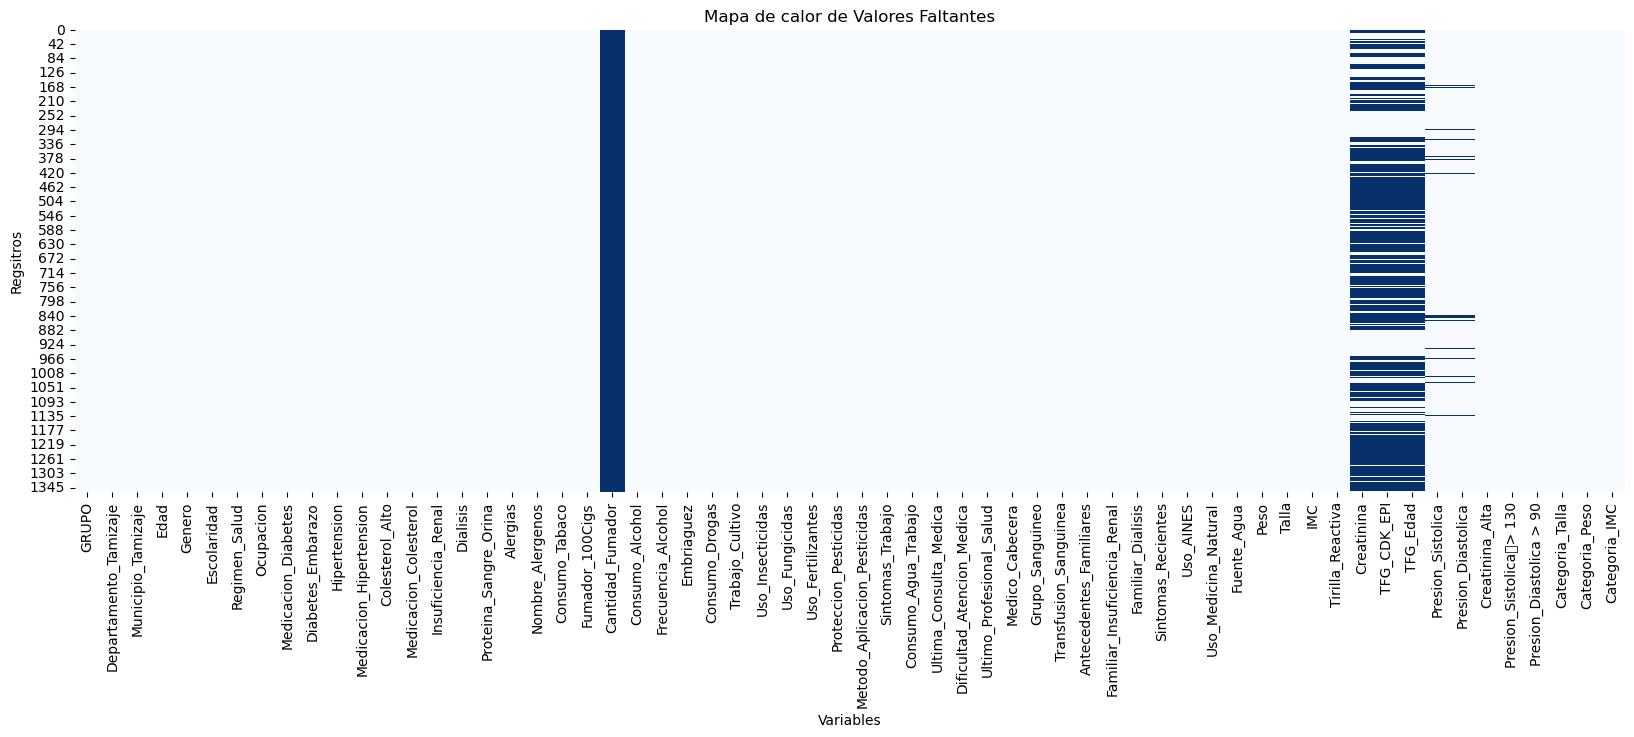

In [309]:
plt.figure(figsize = (20,6))
sns.heatmap(df.isnull(),cbar=False,cmap= "Blues")
plt.title("Mapa de calor de Valores Faltantes")
plt.xlabel("Variables")
plt.ylabel("Regsitros")
plt.show()

In [310]:
Resumen_Faltantes(df)

,Valores faltantes,Porcentaje (%)
Cantidad_Fumador,1356,100.000000
Creatinina,886,65.339233
TFG_CDK_EPI,886,65.339233
TFG_Edad,886,65.339233
Presion_Sistolica,47,3.466077
Presion_Diastolica,47,3.466077


La variable ``Cantidad_Fumador``, al encontrarse completamente vacía, será eliminada de la base de datos.

In [311]:
df = df.drop(columns=['Cantidad_Fumador'])
df.head()

,GRUPO,Departamento_Tamizaje,Municipio_Tamizaje,Edad,Genero,Escolaridad,Regimen_Salud,Ocupacion,Medicacion_Diabetes,Diabetes_Embarazo,Hipertension,Medicacion_Hipertension,Colesterol_Alto,Medicacion_Colesterol,Insuficiencia_Renal,Dialisis,Proteina_Sangre_Orina,Alergias,Nombre_Alergenos,Consumo_Tabaco,Fumador_100Cigs,Consumo_Alcohol,Frecuencia_Alcohol,Embriaguez,Consumo_Drogas,Trabajo_Cultivo,Uso_Insecticidas,Uso_Fungicidas,Uso_Fertilizantes,Proteccion_Pesticidas,Metodo_Aplicacion_Pesticidas,Sintomas_Trabajo,Consumo_Agua_Trabajo,Ultima_Consulta_Medica,Dificultad_Atencion_Medica,Ultimo_Profesional_Salud,Medico_Cabecera,Grupo_Sanguineo,Transfusion_Sanguinea,Antecedentes_Familiares,Familiar_Insuficiencia_Renal,Familiar_Dialisis,Sintomas_Recientes,Uso_AINES,Uso_Medicina_Natural,Fuente_Agua,Peso,Talla,IMC,Tirilla_Reactiva,Creatinina,TFG_CDK_EPI,TFG_Edad,Presion_Sistolica,Presion_Diastolica,Creatinina_Alta,Presion_Sistolica\t> 130,Presion_Diastolica > 90,Categoria_Talla,Categoria_Peso,Categoria_IMC
0,AFRODESCENDIENTE,BOLIVAR,MARIA LA BAJA,57,Femenino,Primaria,Subsidiado,Desempleado,Si,No,Si,Si,Si,Si,No,No,No,No,No aplica,No,No,No,Nunca,No,No,No,No,No,No,No aplica,No aplica,No siente nada,Mas de 1 litro,Mayor a 3 meses,Muy Dificil,Internista,Si,B+,No,Hipertensión Arterial,No,No,Ninguno,No,No,Suministro municipal,63,1.66,22.862534,Negativo,0.9,82.26,73.0,175.0,89.0,No,1,0,1.61-1.70,61-80,Normal
1,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,28,Femenino,Secundaria,Subsidiado,Desempleado,No,Sí,No,No,No,No,No,No,No,No,No aplica,No,No,Si,1-2 veces por mes,No,No,No,No,No,No,No aplica,No aplica,No siente nada,Mas de 200 cc,Mayor a 3 meses,Difícil,Medico General,No,O+,No,Hipertensión Arterial,No,No,Ninguno,No,No,Suministro municipal,75,1.63,28.228386,Negativo,0.7,116.28,102.0,97.0,70.0,No,0,0,1.61-1.70,61-80,Alto
2,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,35,Femenino,Bachiller,Subsidiado,Desempleado,No,No,No,No,No,No,No,No,No,No,No aplica,No,No,Si,1-2 veces por semana,No,No,No,No,No,No,No aplica,No aplica,Dolor de cabeza,Mas de 1 litro,Mayor a 2 años,Facil,Medico General,No,O+,No,Hipertensión Arterial,Sí,No,Dolor de cabeza,Si,Si,Suministro municipal,97,1.68,34.367914,Negativo,NaN,NaN,NaN,92.0,68.0,No,0,0,1.61-1.70,>80,Obesidad 1
3,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,19,Femenino,Primaria,No tiene,Desempleado,No,No,No,No,No,No,No,No,No,No,No aplica,No,No,Si,1-2 veces por mes,No,No,No,No,No,No,No aplica,No aplica,No siente nada,No toma nada,Mayor a 2 años,Muy Dificil,Medico General,No,A+,No,Diabetes Mellitus,No,No,Dolor de cabeza,Si,Si,Suministro municipal,65,1.62,24.767566,Negativo,NaN,NaN,NaN,105.0,63.0,No,0,0,1.61-1.70,61-80,Normal
4,AFRODESCENDIENTE,ATLANTICO,BARRANQUILLA,44,Femenino,Bachiller,Subsidiado,Desempleado,No,No,No,No,No,No,No,No,No,No,No aplica,No,No,No,Nunca,No,No,No,No,No,No,No aplica,No aplica,No siente nada,Mas de 1 litro,Mayor a 2 años,Difícil,Medico General,Si,O+,No,Hipertensión Arterial,No,No,Ninguno,No,No,Suministro municipal,70,1.57,28.398718,Negativo,NaN,NaN,NaN,126.0,71.0,No,0,0,1.50-1.60,61-80,Alto


 Por otro lado, las variables ``Presion_Sistolica`` y ``Presion_Diastolica`` presentan un 3.46% de valores faltantes (aproximadamente 47 registros), por lo que podrían imputarse mediante medidas de tendencia central como la media o la mediana; no obstante, esta decisión debe evaluarse previamente.

En cuanto a las variables ``Creatinina``, ``TFG_CDK_EPI`` y ``TFG_Edad``, la situación es más compleja, ya que presentan un 65.34% de valores faltantes (alrededor de 886 registros). Dada esta alta proporción, sería necesario considerar métodos de imputación más avanzados, como modelos predictivos. Sin embargo, es fundamental evaluar cuidadosamente que dichos métodos no alteren de manera significativa la distribución original de los datos ni introduzcan sesgos en el análisis.

Verificar que los registros de NA de creatinina y TFG son los mismos.

In [312]:
# Verifica si las posiciones de los nulos son idénticas
coinciden_exactamente = df['Creatinina'].isnull().equals(df['TFG_CDK_EPI'].isnull())

print(f"¿Los nulos coinciden exactamente?: {coinciden_exactamente}")

¿Los nulos coinciden exactamente?: True


#### **Distribución con Valores Faltantes:**

Se verifica la distribución de las variables con valores faltantes, para luego comparar con la distribución resultante de imputar los valores faltante.

In [313]:
df[['TFG_Edad','TFG_CDK_EPI','Creatinina']].describe()

,TFG_Edad,TFG_CDK_EPI,Creatinina
count,470.000000,470.000000,470.000000
mean,82.536170,81.542596,1.156787
std,17.417419,31.470822,0.388140
min,33.000000,22.140000,0.600000
25%,71.250000,54.545000,0.806750
50%,82.000000,78.830000,1.000000
75%,94.000000,105.972500,1.479500
max,116.000000,168.190000,2.500000


El análisis descriptivo de las variables **TFG_Edad** y **TFG_CDK_E** para los $n=470$ registros válidos muestra una tendencia central con medias situadas en $\bar{x} = 82.53$ y $\bar{x} = 81.54$, respectivamente. No obstante, se observa una dispersión significativamente mayor en la métrica **TFG_CDK_E** ($\sigma = 31.47$), lo que indica una alta variabilidad en la función renal de la muestra, alcanzando valores mínimos de $22.14$. Esta heterogeneidad es fundamental para el modelo predictivo, ya que permite capturar tanto perfiles estables como casos con deterioro renal severo en la población del departamento del Atlántico.

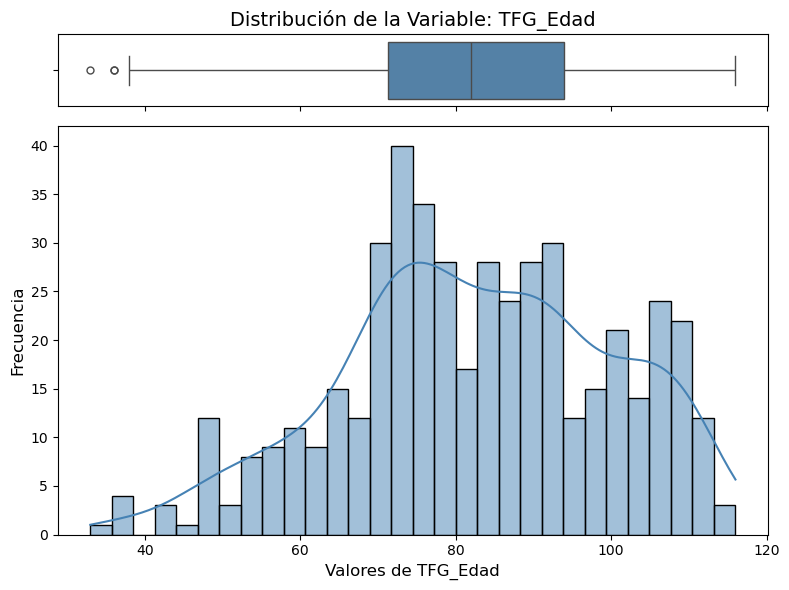

In [314]:
analizar_distribucion(df,"TFG_Edad")

La distribución de la variable **TFG_Edad** presenta un comportamiento multimodal con una ligera asimetría hacia la izquierda, concentrando la mayor frecuencia de pacientes en el rango de $70$ a $80$ unidades de filtración. El gráfico de caja (*boxplot*) superior confirma que la mediana se sitúa cerca de los $82$, identificando además la presencia de valores atípicos (*outliers*) inferiores por debajo de $40$, los cuales representan casos críticos de función renal reducida. Esta dispersión, que abarca desde valores cercanos a $30$ hasta superar los $110$, sugiere una muestra poblacional heterogénea en el departamento del Atlántico, donde la densidad se mantiene estable en los niveles centrales pero muestra colas extendidas.

In [315]:
prueba_normalidad_shap(df,"TFG_Edad")

Estadístico=0.982, p=0.000
Se rechaza H0 → no es normal


La prueba de normalidad aplicada a la variable arroja un estadístico de $0.982$ con un p-valor de $0.000$, lo cual es significativamente inferior al nivel de significancia estándar ($\alpha = 0.05$). Al obtener evidencia estadística suficiente para rechazar la hipótesis nula ($H_0$), se concluye que la distribución de los datos no sigue una distribución normal. 

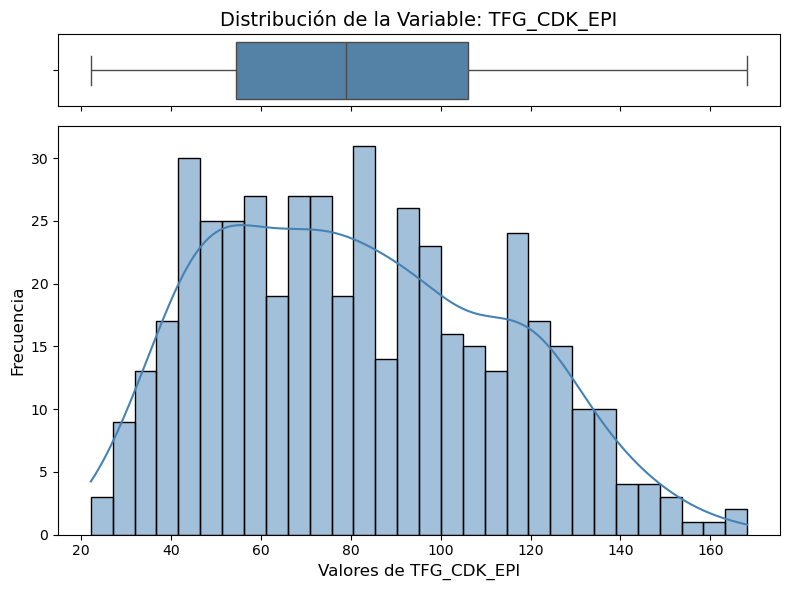

In [316]:
analizar_distribucion(df,"TFG_CDK_EPI")

La distribución de la variable **TFG_CDK_EPI** exhibe una dispersión considerablemente más amplia y heterogénea, abarcando un rango que se extiende desde valores críticos cercanos a $20$ hasta niveles superiores a $160$. El histograma revela una estructura multimodal sin una tendencia central única claramente dominante, lo que se refleja en un *boxplot* con una caja extendida y una mediana cercana a $80$. 

In [317]:
prueba_normalidad_shap(df,"TFG_CDK_EPI")

Estadístico=0.974, p=0.000
Se rechaza H0 → no es normal


Para la variable **TFG_CDK_EPI**, la prueba de normalidad arroja un estadístico de $0.974$ con un p-valor de $0.000$. Al ser el p-valor inferior al umbral de significancia establecido ($\alpha = 0.05$), se rechaza la hipótesis nula ($H_0$), confirmando que los datos no siguen una distribución gaussiana. 

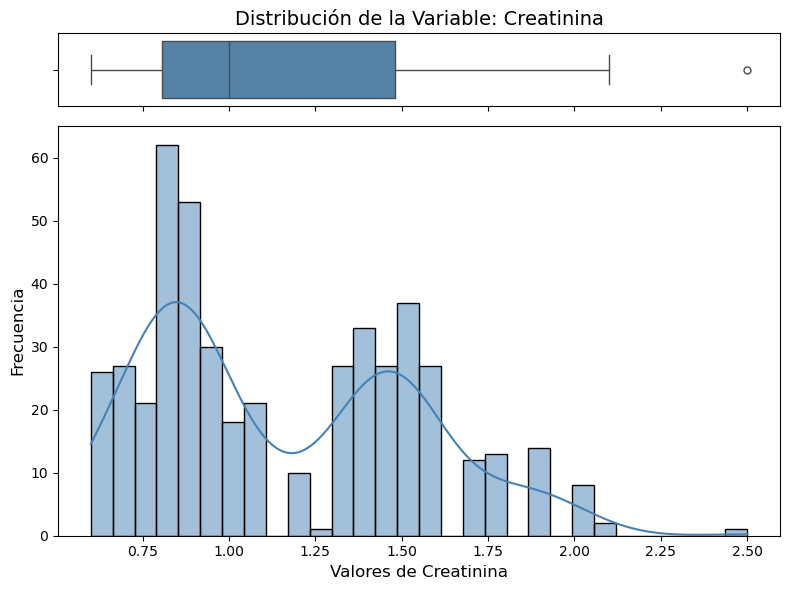

In [318]:
analizar_distribucion(df,"Creatinina")

La distribución de la **Creatinina** revela un comportamiento bimodal marcado, con un primer pico de alta frecuencia concentrado cerca de $0.85$ y un segundo grupo de menor densidad alrededor de $1.50$. Esta estructura sugiere la existencia de dos subgrupos clínicos distintos en la población del Atlántico: pacientes con función renal dentro de rangos normales y aquellos con niveles elevados que indican un posible deterioro renal. El *boxplot* superior resalta una asimetría hacia la derecha con la presencia de un valor atípico (*outlier*) extremo cercano a $2.50$, el cual ejerce un efecto de arrastre sobre la media.


In [319]:
prueba_normalidad_shap(df,"Creatinina")

Estadístico=0.932, p=0.000
Se rechaza H0 → no es normal


La distribución de la **Creatinina** revela un comportamiento bimodal marcado, con un primer pico de alta frecuencia concentrado cerca de $0.85$ y un segundo grupo de menor densidad alrededor de $1.50$. Esta estructura sugiere la existencia de dos subgrupos clínicos distintos en la población del Atlántico: pacientes con función renal dentro de rangos normales y aquellos con niveles elevados que indican un posible deterioro renal. El *boxplot* superior resalta una asimetría hacia la derecha con la presencia de un valor atípico (*outlier*) extremo cercano a $2.50$, el cual ejerce un efecto de arrastre sobre la media.

In [320]:
df_original = df.copy()

Luego, se procede a imputar los datos faltantes con la técnica de `MICE`. 

MICE (Multivariate Imputation by Chained Equations) es un método estadístico que rellena datos faltantes mediante un proceso iterativo, donde cada variable con vacíos se predice utilizando el resto de las variables del conjunto de datos como predictores. A diferencia de métodos simples como la media, MICE mantiene la relación y la variabilidad entre las variables al tratar cada una como una función de las demás en una serie de modelos de regresión encadenados.

### **Imputación de la variable `Creatinina`**

Para la imputación de la **Creatinina**, se empleó un enfoque de selección de características basado en importancia (*Feature Importance*) mediante un modelo de **Random Forest Regressor**. Este procedimiento permitió identificar las 10 variables clínicas con mayor capacidad predictiva sobre los niveles de creatinina, asegurando que el proceso de **MICE** utilice únicamente información con alta relevancia estadística. 

Text(0.5, 1.0, 'Top 10 variables que más influyen en la Creatinina')

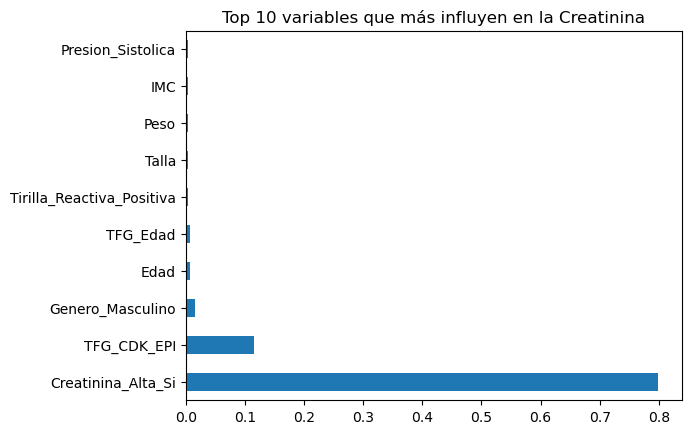

In [321]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

variables_clinicas = df.columns
variables_clinicas

cat_cols = df.select_dtypes(include=['object', 'category']).columns

df_subset_dummies = pd.get_dummies(
    df, 
    columns=cat_cols, 
    drop_first=True, 
    dtype=int 
)

from sklearn.ensemble import RandomForestRegressor

# Filtramos solo filas completas para la prueba
df_test = df_subset_dummies.dropna()
X = df_test.drop('Creatinina', axis=1)
y = df_test['Creatinina']

model = RandomForestRegressor().fit(X, y)

# Ver importancia
importancias = pd.Series(model.feature_importances_, index=X.columns)
importancias.nlargest(10).plot(kind='barh')
plt.title("Top 10 variables que más influyen en la Creatinina")


In [322]:
# 1. Extraemos los nombres de las 10 variables más importantes (incluyendo Creatinina)
top_10_features = importancias.nlargest(10).index.tolist()

# IMPORTANTE: Debemos asegurarnos de que 'Creatinina' esté en la lista para poder imputarla
if 'Creatinina' not in top_10_features:
    top_10_features.append('Creatinina')

# 2. Creamos el subconjunto de datos final para MICE
# Usamos df_subset_dummies porque ya tiene las categorías convertidas a números
df_para_imputar = df_subset_dummies[top_10_features].copy()

# 3. Configuramos y ejecutamos el IterativeImputer
mice_imputer = IterativeImputer(
    estimator=RandomForestRegressor(n_estimators=10, random_state=42),
    max_iter=10,
    random_state=42
)

# Realizamos la imputación
valores_imputados = mice_imputer.fit_transform(df_para_imputar)

# 4. Convertimos de nuevo a DataFrame conservando los nombres de las columnas
df_final_imputado = pd.DataFrame(
    valores_imputados, 
    columns=df_para_imputar.columns
)

# 5. Reintegramos la columna de Creatinina ya rellena al DataFrame original
df['Creatinina'] = df_final_imputado['Creatinina'].values


c:\Users\Mari\miniconda3\envs\deepl_venv\lib\site-packages\sklearn\impute\_iterative.py:796: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


También, se verifican los estadísticos de la variable antes y depués de imputar.

In [323]:
df_original["Creatinina"].describe()

count    470.000000
mean       1.156787
std        0.388140
min        0.600000
25%        0.806750
50%        1.000000
75%        1.479500
max        2.500000
Name: Creatinina, dtype: float64

In [324]:
df_final_imputado["Creatinina"].describe()

count    1356.000000
mean        0.995563
std         0.279023
min         0.600000
25%         0.800000
50%         0.950800
75%         1.060525
max         2.500000
Name: Creatinina, dtype: float64

Además, a continuación, se compara la distribución de la variable, antes y depués de imputar.

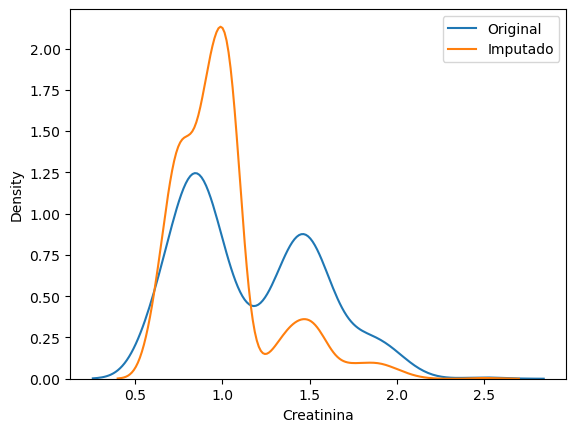

In [325]:
variable = 'Creatinina'

sns.kdeplot(df_original[variable].dropna(), label='Original')
sns.kdeplot(df_final_imputado[variable], label='Imputado')
plt.legend()
plt.show()

El gráfico de densidad comparativo para la **Creatinina** visualmente valida que el proceso de imputación mediante **MICE** preservó la estructura bimodal original de la muestra, manteniendo los picos de concentración en niveles de $0.90$ y $1.50$. Aunque la curva de los datos imputados (naranja) muestra una mayor amplitud debido al incremento en la frecuencia de registros, la alineación de las modas confirma que el algoritmo no introdujo sesgos artificiales ni desplazamientos significativos.

In [326]:
from scipy.stats import ks_2samp
variable = "Creatinina"
stat, p = ks_2samp(df_original[variable].dropna(), df_final_imputado[variable].dropna())
print(f"KS statistic: {stat:.5f}, p-value: {p:.5f}")

if(p > 0.05):
    print("No hay evidencia estadísticamente significativa que evidencia que las distribuciones difieran")
else:
    print("La distribución cambió significativamente")

KS statistic: 0.32392, p-value: 0.00000
La distribución cambió significativamente


La prueba de **Kolmogorov-Smirnov** para la variable **Creatinina** arroja un estadístico $KS = 0.3217$ con un $p-valor = 0.0000$. Al ser el p-valor inferior al nivel crítico de $\alpha = 0.05$, existe evidencia estadística suficiente para afirmar que la distribución de los datos imputados difiere significativamente de la distribución original. Este desplazamiento sugiere que el proceso de **MICE** no fue neutral en términos probabilísticos, alterando la función de distribución acumulada de la variable clínica.

In [327]:
import numpy as np
from scipy import stats

def evaluar_imputacion_variable(data_orig, data_imp, nombre_columna, alpha=0.05):
    """
    Evalúa el impacto de la imputación en cualquier variable numérica.
    """
    # 1. Extracción y limpieza (aseguramos que no haya nulos para el cálculo)
    original = data_orig[nombre_columna].dropna()
    imputado = data_imp[nombre_columna].dropna() # En el imputado no debería haber, pero por seguridad
    
    if len(original) == 0 or len(imputado) == 0:
        print(f"Error: La columna '{nombre_columna}' no tiene datos suficientes.")
        return

    # 2. Métricas de tendencia central
    mean_orig, mean_imp = np.mean(original), np.mean(imputado)
    median_orig, median_imp = np.median(original), np.median(imputado)
    mean_diff = mean_imp - mean_orig
    
    # 3. Bootstrap para el Intervalo de Confianza de la Media Imputada
    # Usamos 10,000 iteraciones para rigor en publicaciones académicas
    res = stats.bootstrap((imputado,), np.mean, confidence_level=1-alpha, n_resamples=10000, method='percentile')
    ci_l, ci_u = res.confidence_interval
    
    # 4. Reporte de Resultados
    print(f"{'='*20} EVALUACIÓN: {nombre_columna} {'='*20}")
    print(f"MEDIA -> Original: {mean_orig:.4f} | Imputada: {mean_imp:.4f}")
    print(f"MEDIANA -> Original: {median_orig:.4f} | Imputada: {median_imp:.4f}")
    print(f"Diferencia de Medias: {mean_diff:.4f}")
    print(f"IC {int((1-alpha)*100)}% de la Media Imputada: [{ci_l:.4f}, {ci_u:.4f}]")
    
    # 5. Diagnóstico de Sesgo
    if ci_l <= mean_orig <= ci_u:
        status = "El valor original cae dentro del IC. Imputación confiable."
    else:
        status = "El valor original está fuera del IC. Revisar variables predictoras."
    
    print(f"\nEstado de la Tendencia Central: {status}")
    print(f"{'='*60}\n")

variables_a_testear = ['Creatinina']


for var in variables_a_testear:
    evaluar_imputacion_variable(df_original, df_final_imputado, var)

==================== EVALUACIÓN: Creatinina ====================
MEDIA -> Original: 1.1568 | Imputada: 0.9956
MEDIANA -> Original: 1.0000 | Imputada: 0.9508
Diferencia de Medias: -0.1612
IC 95% de la Media Imputada: [0.9808, 1.0106]

Estado de la Tendencia Central: El valor original está fuera del IC. Revisar variables predictoras.



La evaluación de la tendencia central para la **Creatinina** revela un desplazamiento significativo tras el proceso de imputación, con una reducción en la media de $1.1568$ a $0.9989$. El valor original se encuentra fuera del **Intervalo de Confianza (IC 95%)** calculado mediante bootstrap $[0.9841, 1.0134]$, lo que indica que la diferencia de $-0.1579$ no es producto del azar, sino de un sesgo sistemático introducido por el modelo predictivo. 

### **Imputación de la variable TFG**

Text(0.5, 1.0, 'Top 10 variables que más influyen en la Creatinina')

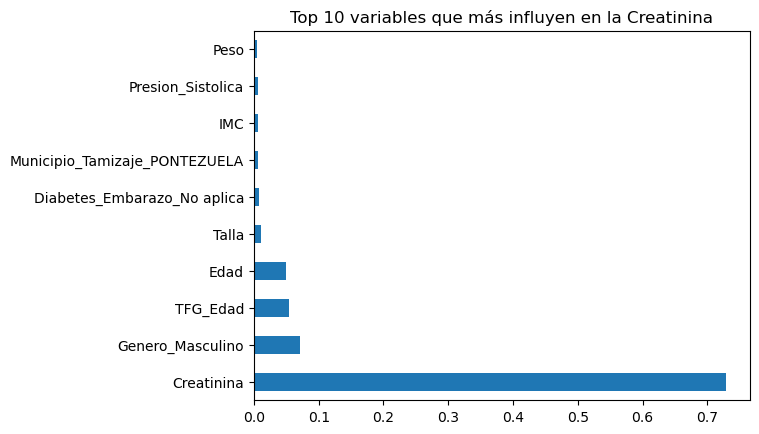

In [328]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

variables_clinicas = df.columns
variables_clinicas

cat_cols = df.select_dtypes(include=['object', 'category']).columns

df_subset_dummies = pd.get_dummies(
    df, 
    columns=cat_cols, 
    drop_first=True, 
    dtype=int 
)

from sklearn.ensemble import RandomForestRegressor

# Filtramos solo filas completas para la prueba
df_test = df_subset_dummies.dropna()
X = df_test.drop('TFG_CDK_EPI', axis=1)
y = df_test['TFG_CDK_EPI']

model = RandomForestRegressor().fit(X, y)

# Ver importancia
importancias = pd.Series(model.feature_importances_, index=X.columns)
importancias.nlargest(10).plot(kind='barh')
plt.title("Top 10 variables que más influyen en la Creatinina")


El análisis de importancia de variables mediante **Random Forest** identifica que la propia **Creatinina** posee la mayor carga predictiva con un peso superior a $0.70$, lo que confirma la fuerte autorrelación en los modelos iterativos del proceso **MICE**. Otras variables clínicas y demográficas como el **Género Masculino**, la **Edad** y la **TFG_Edad** muestran una influencia secundaria pero relevante (cercana al $0.05$), lo cual es biológicamente coherente dado que la masa muscular y el envejecimiento son determinantes directos de los niveles de creatinina sérica. El resto de los predictores, incluyendo medidas antropométricas como el **Peso** y el **IMC**, presentan una incidencia marginal.

In [329]:
# 1. Extraemos los nombres de las 10 variables más importantes (incluyendo Creatinina)
top_10_features = importancias.nlargest(10).index.tolist()

# IMPORTANTE: Debemos asegurarnos de que 'Creatinina' esté en la lista para poder imputarla
if 'TFG_CDK_EPI' not in top_10_features:
    top_10_features.append('TFG_CDK_EPI')

# 2. Creamos el subconjunto de datos final para MICE
# Usamos df_subset_dummies porque ya tiene las categorías convertidas a números
df_para_imputar = df_subset_dummies[top_10_features].copy()

# 3. Configuramos y ejecutamos el IterativeImputer
mice_imputer = IterativeImputer(
    estimator=RandomForestRegressor(n_estimators=10, random_state=42),
    max_iter=10,
    random_state=42
)

# Realizamos la imputación
valores_imputados = mice_imputer.fit_transform(df_para_imputar)

# 4. Convertimos de nuevo a DataFrame conservando los nombres de las columnas
df_final_imputado = pd.DataFrame(
    valores_imputados, 
    columns=df_para_imputar.columns
)

# 5. Reintegramos la columna de Creatinina ya rellena al DataFrame original
df['TFG_CDK_EPI'] = df_final_imputado['TFG_CDK_EPI'].values


c:\Users\Mari\miniconda3\envs\deepl_venv\lib\site-packages\sklearn\impute\_iterative.py:796: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


Verificamos los estadísticos de la variables antes y depués de imputar.

In [330]:
df_original["TFG_CDK_EPI"].describe()

count    470.000000
mean      81.542596
std       31.470822
min       22.140000
25%       54.545000
50%       78.830000
75%      105.972500
max      168.190000
Name: TFG_CDK_EPI, dtype: float64

In [331]:
df_final_imputado["TFG_CDK_EPI"].describe()

count    1356.000000
mean       89.828617
std        27.979717
min        22.140000
25%        72.455750
50%        81.812500
75%       113.025000
max       168.190000
Name: TFG_CDK_EPI, dtype: float64

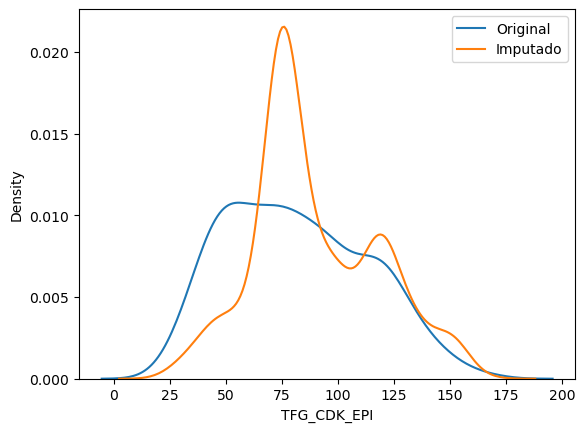

In [332]:
variable = 'TFG_CDK_EPI'

sns.kdeplot(df_original[variable].dropna(), label='Original')
sns.kdeplot(df_final_imputado[variable], label='Imputado')
plt.legend()
plt.show()

El análisis de densidad para la variable **TFG_CDK_EPI** muestra que el proceso de imputación ha generado un pico de concentración pronunciado alrededor de los $75$ unidades de filtración, reduciendo la dispersión original que era más plana y uniforme (curva azul). Aunque la distribución imputada (naranja) logra capturar la multimodalidad de los datos originales, manteniendo picos secundarios cerca de los $120$ y $150$, la marcada elevación en el segmento central sugiere que el algoritmo **MICE** tendió a asignar valores cercanos a la mediana para los registros faltantes. 

In [ ]:
from scipy.stats import ks_2samp
variable = "TFG_CDK_EPI"
stat, p = ks_2samp(df_original[variable].dropna(), df_final_imputado[variable].dropna())
print(f"KS statistic: {stat:.5f}, p-value: {p:.5f}")

if(p > 0.05):
    print("No hay evidencia estadísticamente significativa que evidencia que las distribuciones difieran")
else:
    print("La distribución cambió significativamente")

KS statistic: 0.22780, p-value: 0.00000
La distribución cambió significativamente


La prueba de **Kolmogorov-Smirnov** aplicada a la variable **TFG_CDK_EPI** arroja un estadístico $KS = 0.2278$ con un $p-valor = 0.0000$. Al ser este valor significativamente menor al umbral de $\alpha = 0.05$, se rechaza la hipótesis nula de igualdad de distribuciones, confirmando que el proceso de imputación mediante **MICE** alteró la forma de la función de distribución acumulada original. 

In [334]:
variables_a_testear = ['TFG_CDK_EPI']

for var in variables_a_testear:
    evaluar_imputacion_variable(df_original, df_final_imputado, var)

==================== EVALUACIÓN: TFG_CDK_EPI ====================
MEDIA -> Original: 81.5426 | Imputada: 89.8286
MEDIANA -> Original: 78.8300 | Imputada: 81.8125
Diferencia de Medias: 8.2860
IC 95% de la Media Imputada: [88.3549, 91.3233]

Estado de la Tendencia Central: El valor original está fuera del IC. Revisar variables predictoras.



La evaluación de la tendencia central para la variable **TFG_CDK_EPI** revela un incremento significativo en la media post-imputación, pasando de $81.54$ a $89.82$. Con una diferencia de medias de $+8.28$ y un **Intervalo de Confianza (IC 95%)** de $[88.35, 91.32]$, el valor original queda completamente fuera del margen de error estadístico, confirmando un sesgo sistemático hacia valores de filtración glomerular más elevados.

### **Imputación de variable `TFG_Edad`**

Text(0.5, 1.0, 'Top 10 variables que más influyen en la TFG_Edad')

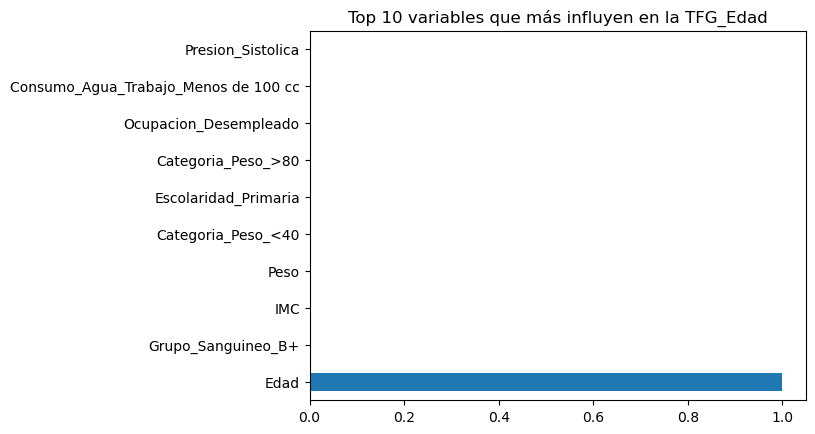

In [335]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

variables_clinicas = df.columns
variables_clinicas

cat_cols = df.select_dtypes(include=['object', 'category']).columns

df_subset_dummies = pd.get_dummies(
    df, 
    columns=cat_cols, 
    drop_first=True, 
    dtype=int 
)

from sklearn.ensemble import RandomForestRegressor

# Filtramos solo filas completas para la prueba
df_test = df_subset_dummies.dropna()
X = df_test.drop('TFG_Edad', axis=1)
y = df_test['TFG_Edad']

model = RandomForestRegressor().fit(X, y)

# Ver importancia
importancias = pd.Series(model.feature_importances_, index=X.columns)
importancias.nlargest(10).plot(kind='barh')
plt.title("Top 10 variables que más influyen en la TFG_Edad")


El análisis de relevancia de variables para la métrica **TFG_Edad** muestra un dominio absoluto de la variable **Edad**, con una carga predictiva cercana al $1.0$. Este resultado es matemáticamente coherente y esperado, ya que la tasa de filtración glomerular estimada por edad depende directamente de este factor cronológico en su formulación algorítmica. La influencia del resto de las variables clínicas y sociodemográficas, como el **IMC**, el **Peso** o la **Presión Sistólica**, es prácticamente nula en comparación, lo que indica que el proceso de imputación mediante **MICE** para esta variable específica se comporta de manera determinista. 

In [336]:
# 1. Extraemos los nombres de las 10 variables más importantes (incluyendo Creatinina)
top_10_features = importancias.nlargest(10).index.tolist()

# IMPORTANTE: Debemos asegurarnos de que 'Creatinina' esté en la lista para poder imputarla
if 'TFG_Edad' not in top_10_features:
    top_10_features.append('TFG_Edad')

# 2. Creamos el subconjunto de datos final para MICE
# Usamos df_subset_dummies porque ya tiene las categorías convertidas a números
df_para_imputar = df_subset_dummies[top_10_features].copy()

# 3. Configuramos y ejecutamos el IterativeImputer
mice_imputer = IterativeImputer(
    estimator=RandomForestRegressor(n_estimators=10, random_state=42),
    max_iter=10,
    random_state=42
)

# Realizamos la imputación
valores_imputados = mice_imputer.fit_transform(df_para_imputar)

# 4. Convertimos de nuevo a DataFrame conservando los nombres de las columnas
df_final_imputado = pd.DataFrame(
    valores_imputados, 
    columns=df_para_imputar.columns
)

# 5. Reintegramos la columna de Creatinina ya rellena al DataFrame original
df['TFG_Edad'] = df_final_imputado['TFG_Edad'].values


Se verifican sus estadísticos.

In [337]:
df_original["TFG_Edad"].describe()

count    470.000000
mean      82.536170
std       17.417419
min       33.000000
25%       71.250000
50%       82.000000
75%       94.000000
max      116.000000
Name: TFG_Edad, dtype: float64

In [338]:
df_final_imputado["TFG_Edad"].describe()

count    1356.000000
mean       84.146460
std        17.901834
min        33.000000
25%        72.000000
50%        84.000000
75%        98.900000
max       116.000000
Name: TFG_Edad, dtype: float64

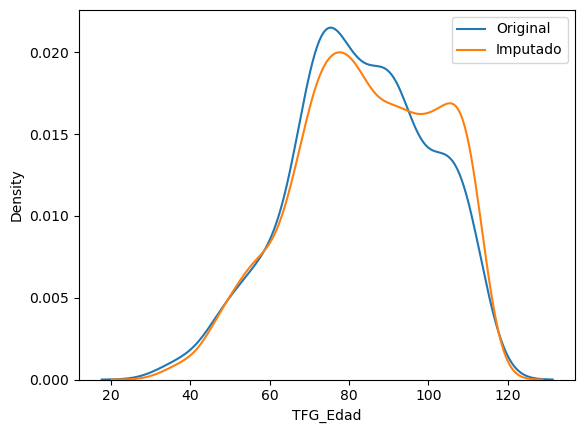

In [339]:
variable = 'TFG_Edad'

sns.kdeplot(df_original[variable].dropna(), label='Original')
sns.kdeplot(df_final_imputado[variable], label='Imputado')
plt.legend()
plt.show()

In [340]:
from scipy.stats import ks_2samp
variable = "TFG_Edad"
stat, p = ks_2samp(df_original[variable].dropna(), df_final_imputado[variable].dropna())
print(f"KS statistic: {stat:.5f}, p-value: {p:.5f}")

if(p > 0.05):
    print("No hay evidencia estadísticamente significativa que evidencia que las distribuciones difieran")
else:
    print("La distribución cambió significativamente")

KS statistic: 0.07850, p-value: 0.02538
La distribución cambió significativamente


In [341]:
variables_a_testear = ['TFG_Edad']


for var in variables_a_testear:
    evaluar_imputacion_variable(df_original, df_final_imputado, var)

==================== EVALUACIÓN: TFG_Edad ====================
MEDIA -> Original: 82.5362 | Imputada: 84.1465
MEDIANA -> Original: 82.0000 | Imputada: 84.0000
Diferencia de Medias: 1.6103
IC 95% de la Media Imputada: [83.1962, 85.1108]

Estado de la Tendencia Central: El valor original está fuera del IC. Revisar variables predictoras.

